In [34]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GRU

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [58]:
df = pd.read_csv("gold_xau.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df.head()

,date,price
5275,2011-06-01,1540.20
5274,2011-06-02,1531.90
5273,2011-06-03,1540.50
5272,2011-06-06,1542.00
5271,2011-06-07,1543.75


In [59]:
df.tail()

,date,price
4,2026-05-14,4696.48
3,2026-05-15,4648.07
2,2026-05-16,4540.15
1,2026-05-17,4540.42
0,2026-05-18,4526.97


In [3]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 5276 entries, 5275 to 0
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    5276 non-null   datetime64[ns]
 1   price   5276 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 123.7 KB
None
                                date        price
count                           5276  5276.000000
mean   2019-02-17 22:17:55.360121344  1783.168275
min              2011-06-01 00:00:00  1050.730000
25%              2015-07-18 18:00:00  1280.702500
50%              2019-02-26 12:00:00  1597.765000
75%              2022-10-07 06:00:00  1900.000000
max              2026-05-18 00:00:00  5477.790000
std                              NaN   778.778571
date     0
price    0
dtype: int64


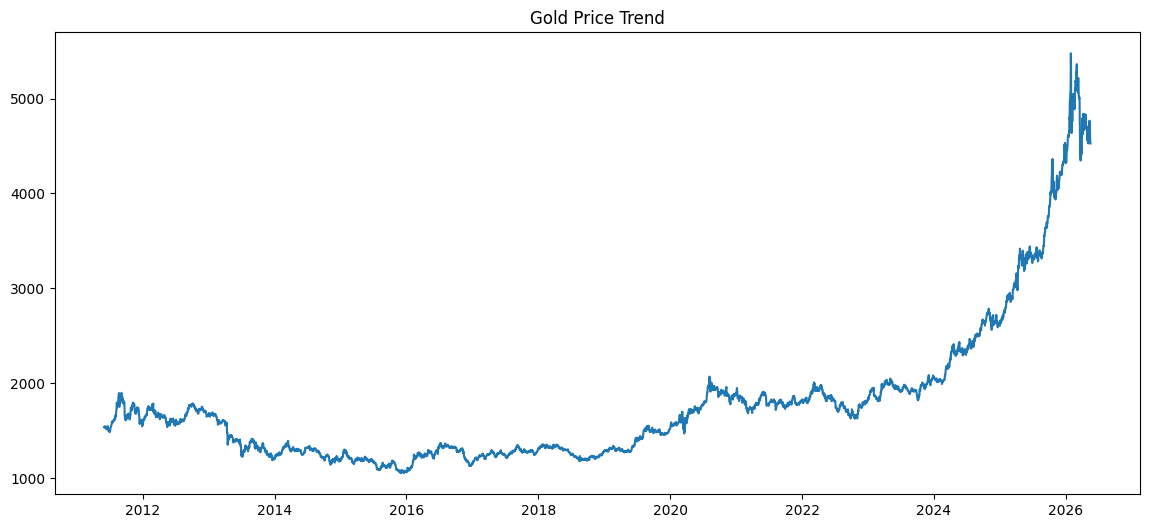

In [4]:
plt.figure(figsize=(14,6))
plt.plot(df["date"], df["price"])
plt.title("Gold Price Trend")
plt.show()

In [5]:
data = df[["price"]].values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [6]:
def create_dataset(data, look_back=60):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

look_back = 60
X, y = create_dataset(data_scaled, look_back)

X = X.reshape(X.shape[0], X.shape[1], 1)

In [7]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [8]:
val_size = int(len(X_train) * 0.1)

X_val = X_train[-val_size:]
y_val = y_train[-val_size:]

X_train_final = X_train[:-val_size]
y_train_final = y_train[:-val_size]

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [41]:
def build_rnn():
    model = Sequential([
        SimpleRNN(64, activation='tanh', input_shape=(look_back, 1)),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse')
    return model

In [42]:
def build_lstm():
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(look_back, 1)),
        LSTM(25),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.0005), loss='mse')
    return model

In [39]:
def build_gru():
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(look_back, 1)),
        GRU(25),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.0005), loss='mse')
    return model

In [44]:
print("Training RNN...")
rnn = build_rnn()
rnn.fit(X_train_final, y_train_final,
        validation_data=(X_val, y_val),
        epochs=150, batch_size=32,
        shuffle=False, callbacks=[early_stop], verbose=1)

print("Training LSTM...")
lstm = build_lstm()
lstm.fit(X_train_final, y_train_final,
         validation_data=(X_val, y_val),
         epochs=150, batch_size=32,
         shuffle=False, callbacks=[early_stop], verbose=1)

print("Training GRU...")
gru = build_gru()
gru.fit(X_train_final, y_train_final,
        validation_data=(X_val, y_val),
        epochs=150, batch_size=32,
        shuffle=False, callbacks=[early_stop], verbose=1)

Training RNN...
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 7.9055e-04 - val_loss: 8.7465e-04
Epoch 2/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.2327e-04 - val_loss: 1.8486e-04
Epoch 3/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.2172e-04 - val_loss: 1.7146e-04
Epoch 4/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.9305e-04 - val_loss: 2.0028e-04
Epoch 5/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.2277e-04 - val_loss: 2.4519e-04
Epoch 6/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.7244e-04 - val_loss: 3.2731e-04
Epoch 7/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.4149e-04 - val_loss: 4.2313e-04
Epoch 8/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.8916e-04 - val_loss: 4.7813e-04
Epoch 9/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.3854e-04 - val_loss: 3.8493e-04
Epoch 10/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.9634e-04 - val_loss: 1.9611e-04
Epoch 11/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss

In [45]:
pred_rnn = scaler.inverse_transform(rnn.predict(X_test))
pred_lstm = scaler.inverse_transform(lstm.predict(X_test))
pred_gru = scaler.inverse_transform(gru.predict(X_test))

y_test_actual = scaler.inverse_transform(y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [47]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

In [48]:
rnn_mae, rnn_rmse = evaluate(y_test_actual, pred_rnn)
lstm_mae, lstm_rmse = evaluate(y_test_actual, pred_lstm)
gru_mae, gru_rmse = evaluate(y_test_actual, pred_gru)

print("\n===== 80–20 RESULTS =====")
print("RNN  MAE:", rnn_mae, "RMSE:", rnn_rmse)
print("LSTM MAE:", lstm_mae, "RMSE:", lstm_rmse)
print("GRU  MAE:", gru_mae, "RMSE:", gru_rmse)


===== 80–20 RESULTS =====
RNN  MAE: 2818.2969266941236 RMSE: 2832.861640499048
LSTM MAE: 1915.7033987205616 RMSE: 1927.3941066487039
GRU  MAE: 2030.1119769021739 RMSE: 2039.205633077159


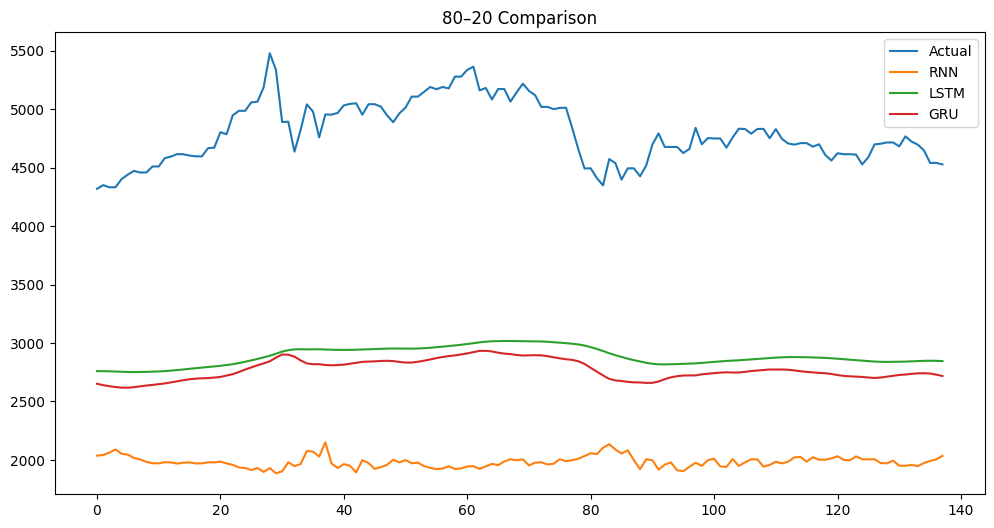

In [49]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual")
plt.plot(pred_rnn, label="RNN")
plt.plot(pred_lstm, label="LSTM")
plt.plot(pred_gru, label="GRU")
plt.legend()
plt.title("80–20 Comparison")
plt.show()

In [50]:
train_df = df[df["date"].dt.year < 2026]
test_df = df[df["date"].dt.year == 2026]

In [51]:
train_scaled = scaler.fit_transform(train_df[["price"]])
test_scaled = scaler.transform(test_df[["price"]])

In [52]:
X_train2, y_train2 = create_dataset(train_scaled, look_back)

X_test2, y_test2 = create_dataset(
    np.concatenate([train_scaled[-look_back:], test_scaled]),
    look_back
)

X_train2 = X_train2.reshape(X_train2.shape[0], look_back, 1)
X_test2 = X_test2.reshape(X_test2.shape[0], look_back, 1)

In [53]:
rnn2 = build_rnn()
lstm2 = build_lstm()
gru2 = build_gru()

rnn2.fit(X_train2, y_train2,
         validation_data=(X_test2, y_test2),
         epochs=150, batch_size=32,
         shuffle=False, callbacks=[early_stop], verbose=1)

lstm2.fit(X_train2, y_train2,
          validation_data=(X_test2, y_test2),
          epochs=150, batch_size=32,
          shuffle=False, callbacks=[early_stop], verbose=1)

gru2.fit(X_train2, y_train2,
         validation_data=(X_test2, y_test2),
         epochs=150, batch_size=32,
         shuffle=False, callbacks=[early_stop], verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
159/159 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0021 - val_loss: 0.0137
Epoch 2/150
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0020 - val_loss: 0.0031
Epoch 3/150
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0031 - val_loss: 0.0095
Epoch 4/150
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.6762e-04 - val_loss: 0.0034
Epoch 5/150
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.1347e-04 - val_loss: 0.0040
Epoch 6/150
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7454e-04 - val_loss: 0.0019
Epoch 7/150
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.5898e-05 - val_loss: 0.0016
Epoch 8/150
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.2977e-05 - val_loss: 0.0012
Epoch 9/150
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4332e-05 - val_loss: 0.0012
Epoch 10/150
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.5023e-05 - val_loss: 0.0013
Epoch 11/150
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.1290e-05 - val_loss: 0.0014
Epoch 12

In [54]:
pred_rnn_2026 = scaler.inverse_transform(rnn2.predict(X_test2))
pred_lstm_2026 = scaler.inverse_transform(lstm2.predict(X_test2))
pred_gru_2026 = scaler.inverse_transform(gru2.predict(X_test2))

y_2026_actual = scaler.inverse_transform(y_test2)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [55]:
rnn_mae2, rnn_rmse2 = evaluate(y_2026_actual, pred_rnn_2026)
lstm_mae2, lstm_rmse2 = evaluate(y_2026_actual, pred_lstm_2026)
gru_mae2, gru_rmse2 = evaluate(y_2026_actual, pred_gru_2026)

print("\n===== 2026 RESULTS =====")
print("RNN  MAE:", rnn_mae2, "RMSE:", rnn_rmse2)
print("LSTM MAE:", lstm_mae2, "RMSE:", lstm_rmse2)
print("GRU  MAE:", gru_mae2, "RMSE:", gru_rmse2)


===== 2026 RESULTS =====
RNN  MAE: 331.85579030797106 RMSE: 407.6625692027994
LSTM MAE: 162.68794667119568 RMSE: 211.78739494799453
GRU  MAE: 105.93599637681163 RMSE: 141.85497515536736


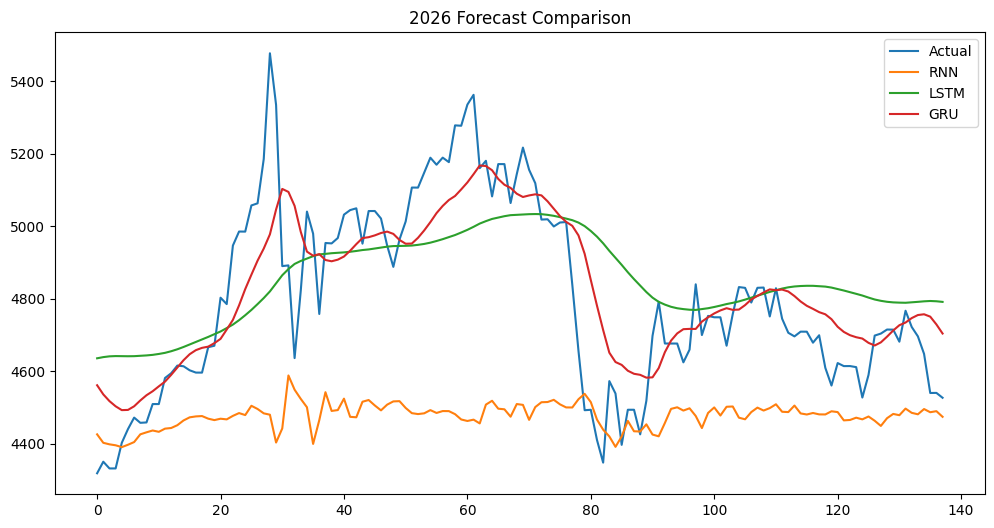

In [56]:
plt.figure(figsize=(12,6))
plt.plot(y_2026_actual, label="Actual")

plt.plot(pred_rnn_2026, label="RNN")
plt.plot(pred_lstm_2026, label="LSTM")
plt.plot(pred_gru_2026, label="GRU")

plt.legend()
plt.title("2026 Forecast Comparison")
plt.show()

# **Conclusion**

### RNN, LSTM, and GRU models were used to predict gold prices from historical XAU/USD data. Among the three, GRU achieved the best performance, followed by LSTM and RNN. The results show that deep learning models can capture gold price trends effectively, though long-term forecasts become less accurate due to error accumulation. Overall, GRU was the most effective model for this dataset.